### SCENARIO 1 — LOAN DEFAULT / CREDIT RISK
Business Problem

A bank receives *100,000* loan applications per month.

The bank currently uses manually defined rules to approve/reject applications.

Management wants an ML system that predicts:

> “What is the probability that this applicant will default?”

The bank wants to reduce financial losses while still approving good customers.

### Workflow
1. Import libraries
2. Load the Loan Default dataset
3. Inspect data
4. Check missing values and duplicates
5. Perform descriptive statistics and visual EDA
6. Encode categorical variables
7. Scale features
8. Split train/test data
9. Train and compare multiple classification models
10. Evaluate XGBoost
11. Inspect feature importance
12. Generate a confusion matrix and classification report


In [ ]:
# Import numpy as np # linear algebra so its functions/classes can be used in this notebook.
import numpy as np # linear algebra

# Import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv) so its functions/classes can be used in this notebook.
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Import matplotlib.pyplot as plt so its functions/classes can be used in this notebook.
import matplotlib.pyplot as plt

# Import seaborn as sns so its functions/classes can be used in this notebook.
import seaborn as sns

# Import warnings so its functions/classes can be used in this notebook.
import warnings


# Hide warning messages so the notebook output stays cleaner.
warnings.filterwarnings('ignore')

In [63]:
import os

folder = r"D:\ML_Problem_Solving\1.Loan_Default_Prediction"

print(os.listdir(folder))

['1_Loan_Default_Prediction.ipynb', 'Loan_default - Loan_default.csv', 'Loan_Default_Prediction.ipynb']


In [64]:
import pandas as pd

# Load the Loan Default CSV file into a pandas DataFrame named df.

df = pd.read_csv(
    r"D:\ML_Problem_Solving\1.Loan_Default_Prediction\Loan_default - Loan_default.csv"
)

print("Shape:", df.shape) # Return the dataset dimensions as (number of rows, number of columns).


df.head() # Display the first 5 rows to quickly inspect the dataset.


Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [65]:
df.info() # Display column names, data types, non-null counts, and memory information.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [66]:
df.isnull().sum()  # Count missing values in every column.


LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [67]:
df.tail()  # Display the last 5 rows to inspect the end of the dataset.


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255346,ZTH91CGL0B,62,22418,18481,636,113,2,6.73,12,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


In [68]:
df.drop(index=247966, inplace=True) # Remove the specified row index from df and modify df directly with inplace=True.


In [69]:
df[df.duplicated()]  # Find rows that are exact duplicates of earlier rows.


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default


# Descriptive Statistics

In [78]:
df.describe().transpose()  # Generate descriptive statistics for numeric columns and transpose the result for easier reading.


,count,mean,std,min,25%,50%,75%,max
Age,255346.0,43.498273,14.990278,18.0,31.00,43.00,56.00,69.0
Income,255346.0,82499.563549,38962.870295,15000.0,48826.00,82466.50,116219.00,149999.0
LoanAmount,255346.0,127579.283690,70840.529690,5000.0,66156.25,127556.50,188985.50,249999.0
CreditScore,255346.0,574.264966,158.903869,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255346.0,59.542155,34.643326,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255346.0,2.501042,1.117016,1.0,2.00,2.00,3.00,4.0
InterestRate,255346.0,13.492730,6.636420,2.0,7.77,13.46,19.25,25.0
LoanTerm,255346.0,36.025941,16.969347,12.0,24.00,36.00,48.00,60.0
DTIRatio,255346.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255346.0,0.116129,0.320380,0.0,0.00,0.00,0.00,1.0


# Visualization

**Age Distribution**

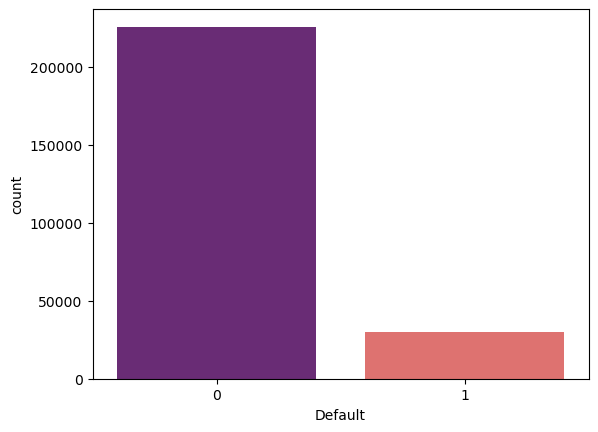

In [71]:
# Create a count plot showing how many observations belong to each Default class.
sns.countplot(x = 'Default', data =df, palette = 'magma')

# Render the current matplotlib/seaborn figure.
plt.show()

In [72]:
# Select numeric columns, then remove target/selected columns that are not being used in this numeric analysis.
df_num = df.select_dtypes(exclude = ['object']).drop(['Default','DTIRatio','LoanTerm'], axis = 1)

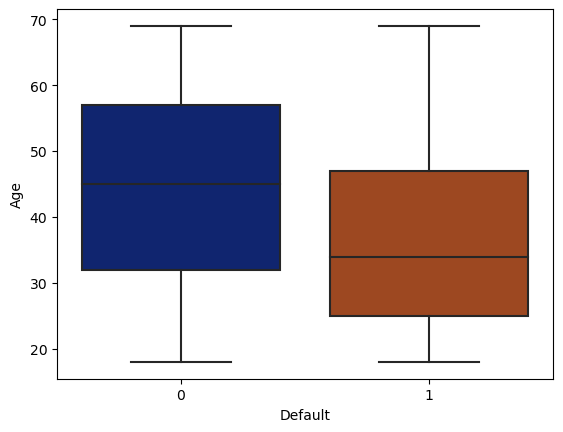

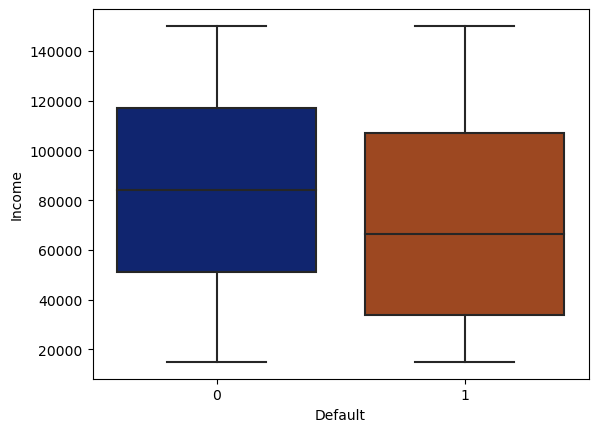

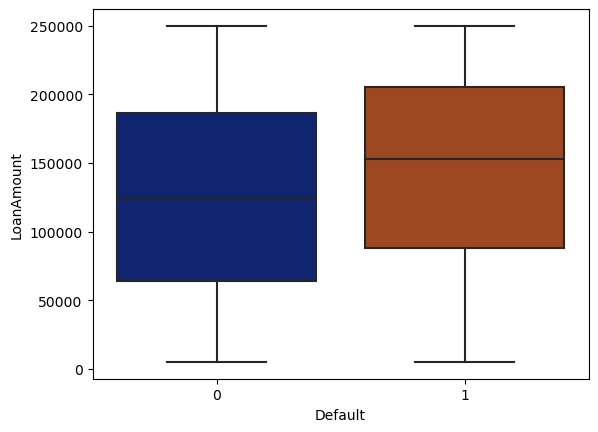

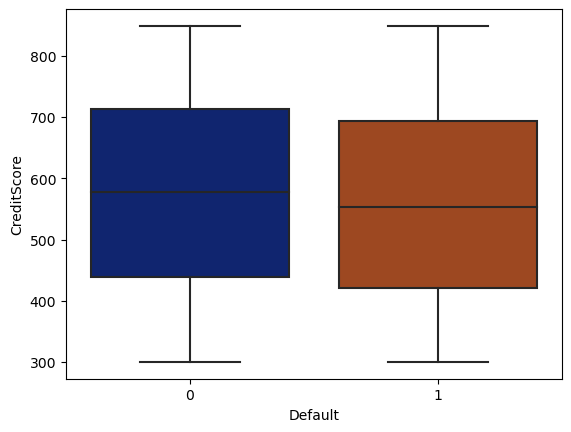

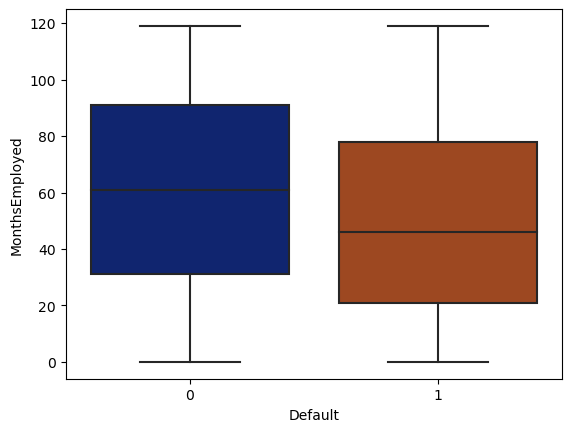

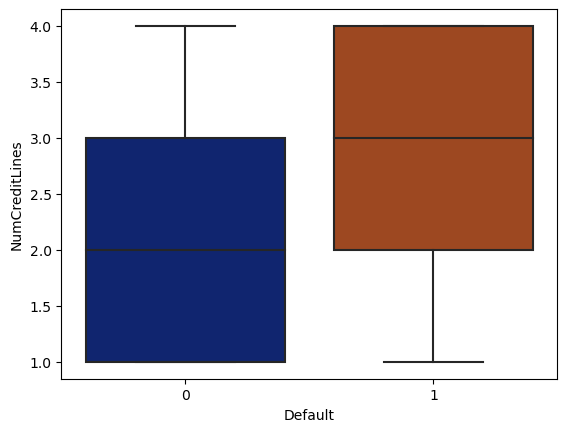

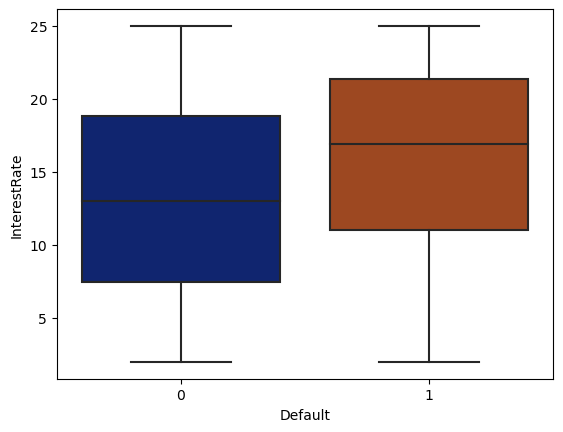

In [73]:
# Loop through each selected numeric feature.
for col in df_num:
    # Draw a boxplot of the current feature grouped by the Default target to compare distributions and outliers.
    sns.boxplot(x = 'Default' , y = df[col], data =df , palette = 'dark')
    # Render the current matplotlib/seaborn figure.
    plt.show()

# Interpretation

1. Older people are seen less likely to default

2. The dafaulters are seen with lower avg income

3. The dafaulters are seen with larger Loan Amount and lesser credit score

4. People having higher Interest rate are more likely to default

# Correlation

In [74]:
# Calculate pairwise Pearson correlations between the selected numeric features.
df_num.corr()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate
Age,1.000000,-0.001240,-0.002209,-0.000546,-0.000338,-0.000887,-0.001131
Income,-0.001240,1.000000,-0.000875,-0.001437,0.002666,-0.002025,-0.002292
LoanAmount,-0.002209,-0.000875,1.000000,0.001255,0.002809,0.000786,-0.002281
CreditScore,-0.000546,-0.001437,0.001255,1.000000,0.000608,0.000011,0.000443
MonthsEmployed,-0.000338,0.002666,0.002809,0.000608,1.000000,0.001260,0.000104
NumCreditLines,-0.000887,-0.002025,0.000786,0.000011,0.001260,1.000000,-0.000288
InterestRate,-0.001131,-0.002292,-0.002281,0.000443,0.000104,-0.000288,1.000000


<Axes: >

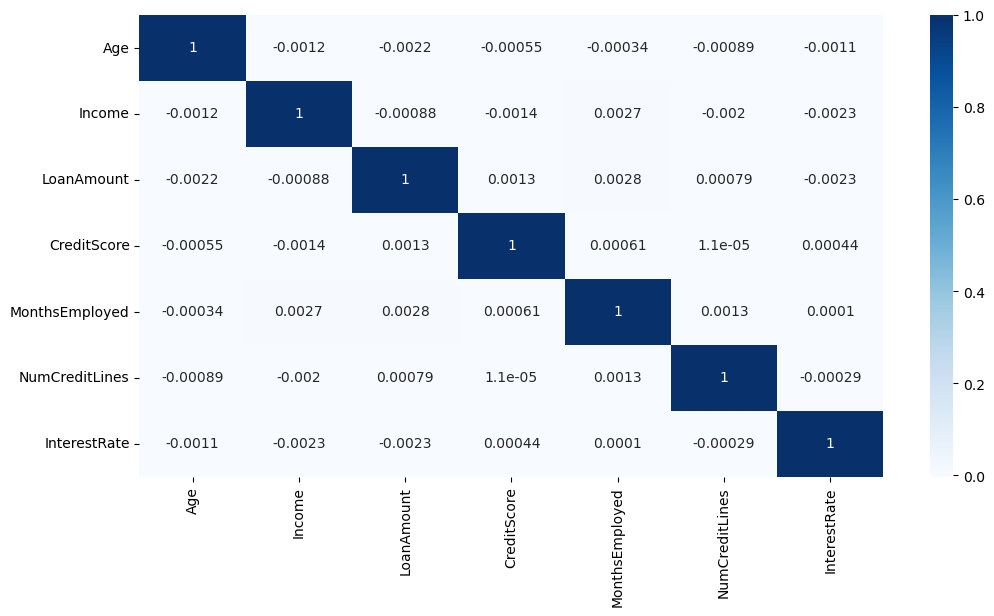

In [75]:
# Create a new figure and set its size in inches.
plt.figure(figsize = (12,6))
# Visualize the correlation matrix as a heatmap; annot=True prints correlation values in the cells.
sns.heatmap(df_num.corr(), annot = True, cmap = 'Blues')

**No significant correlation found**

# **ScatterPlot**

<Axes: xlabel='Income', ylabel='LoanAmount'>

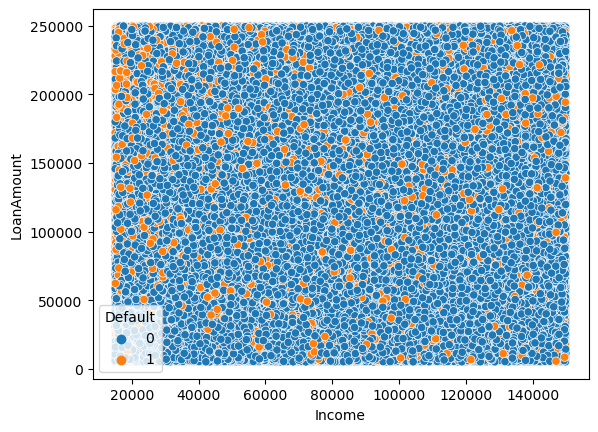

In [76]:
# Plot Income against LoanAmount and color points by Default to inspect relationships and class separation.
sns.scatterplot( x = 'Income' , y = 'LoanAmount', data =df,hue = 'Default')

No as such relationship found , the defaulters are spread between both low and high income